In [3]:
%load_ext autoreload
%autoreload 2


In [4]:
from pathlib import Path

from audio_classification_playground.synthetic.generator import generate_synthetic_audio
from audio_classification_playground.synthetic import visualize_synthetic

In [5]:
res = generate_synthetic_audio(
    output_dir=Path("../outputs"),
    resources_dir=Path("../resources"),
)

Generating 180.0s synthetic audio...
Resources: ../resources
Output: ../outputs

[1/5] Loading audio sources...
Loaded speech: sample_1.wav (16.77s)
Loaded speech: sample_2.wav (15.18s)
Loaded speech: sample_3.wav (16.05s)
Loaded speech: sample_4.wav (15.42s)
Loaded speech: sample_5.wav (15.60s)
Loaded music: sample_1.wav (15.00s)
Loaded music: sample_2.wav (15.00s)
Loaded music: sample_3.wav (15.00s)
Loaded music: sample_4.wav (15.00s)
Loaded music: sample_5.wav (15.00s)
Loaded sfx: car_horn_10.wav (5.00s)
Loaded sfx: car_horn_7.wav (5.00s)
Loaded sfx: clapping_3.wav (5.00s)
Loaded sfx: clapping_4.wav (5.00s)
Loaded sfx: crickets_14.wav (5.00s)
Loaded sfx: crickets_15.wav (5.00s)
Loaded sfx: engine_8.wav (5.00s)
Loaded sfx: engine_9.wav (5.00s)
Loaded sfx: fireworks_5.wav (5.00s)
Loaded sfx: fireworks_6.wav (5.00s)
Loaded sfx: glass_breaking_11.wav (5.00s)
Loaded sfx: sea_waves_12.wav (5.00s)
Loaded sfx: sea_waves_13.wav (5.00s)
Loaded sfx: thunderstorm_1.wav (5.00s)
Loaded sfx: thund

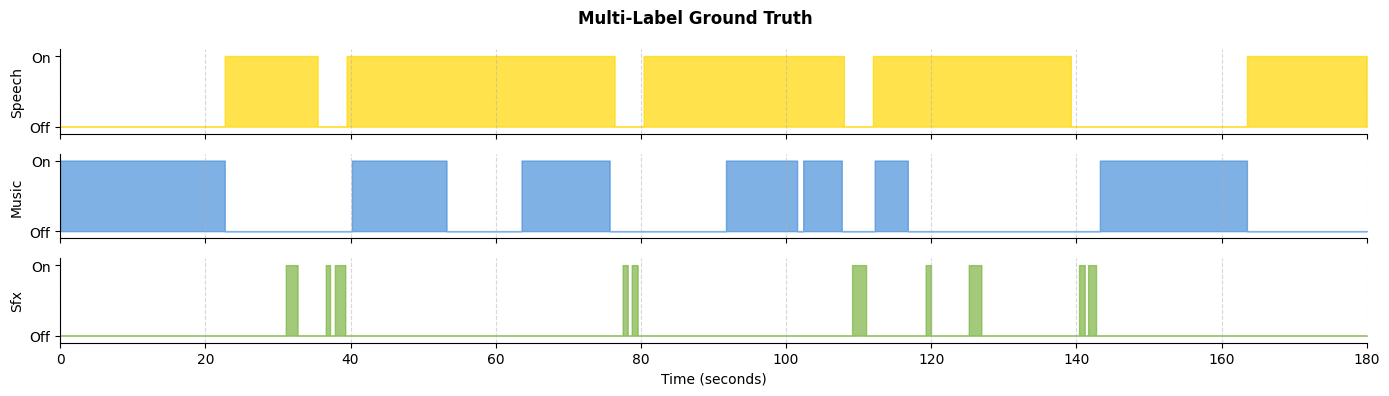

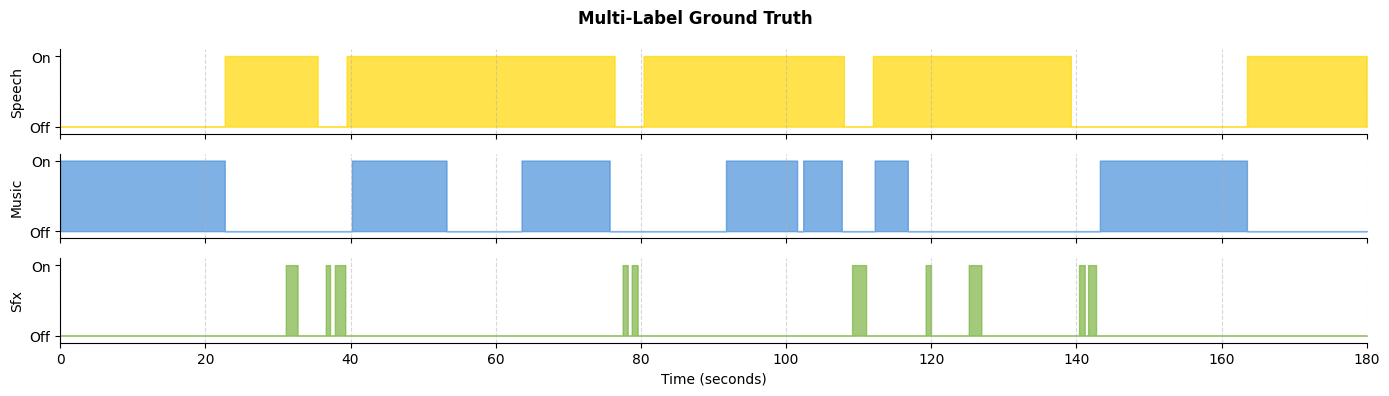

In [6]:
from audio_classification_playground.synthetic import visualize_synthetic


visualize_synthetic.plot_labels(
    labels=res.labels,
)

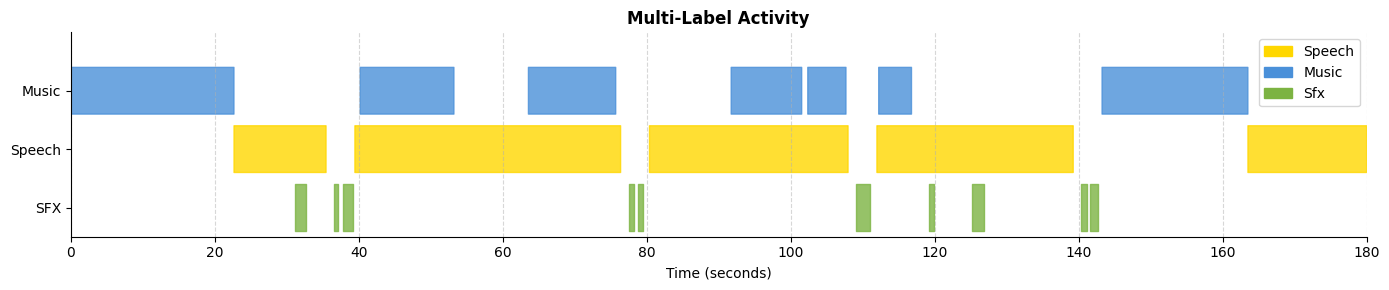

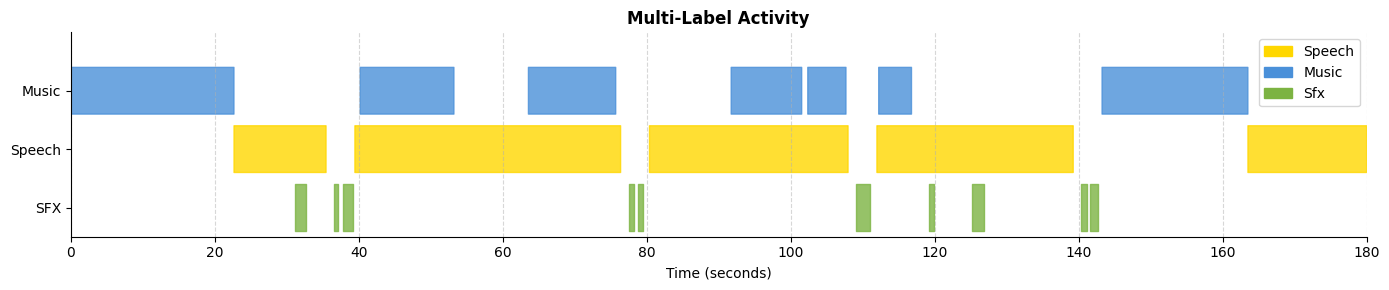

In [7]:
visualize_synthetic.plot_labels_combined(
    labels=res.labels,
)

In [8]:
from audio_classification_playground.panns import inference

In [9]:
model = inference.load_model(checkpoint_path=Path("../resources/models/Cnn14_DecisionLevelMax_mAP=0.385.pth"))

/Users/dvir.benor/PycharmProjects/audio-classification-playground/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CPU.


In [10]:
frame_wise_output = inference.frame_level_inference(model, res.audio)

/Users/dvir.benor/PycharmProjects/audio-classification-playground/audio_classification_playground/panns/visualize.py:28: RuntimeWarning: divide by zero encountered in log
  axs[0].matshow(np.log(np.abs(stft)), origin='lower', aspect='auto', cmap='jet')


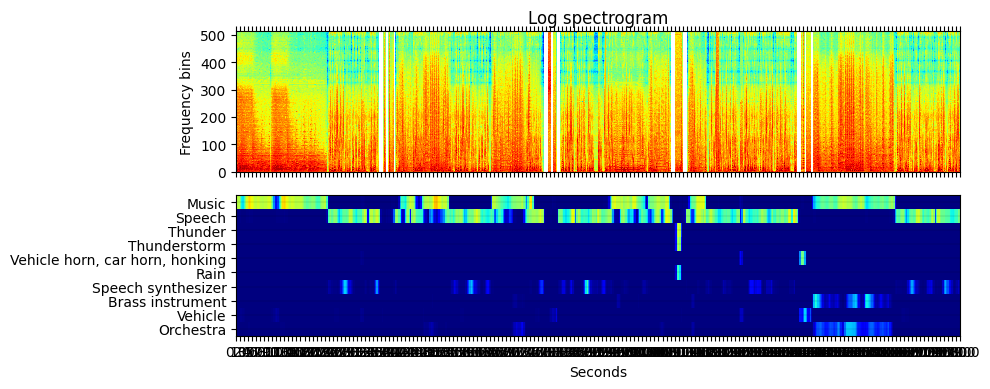

In [14]:
from audio_classification_playground.panns.visualize import visualize_frame_level_output,visualize_high_level_categories
visualize_frame_level_output(
    raw_audio=res.audio,
    framewise_output=frame_wise_output,
)

<string>:20: RuntimeWarning: divide by zero encountered in log


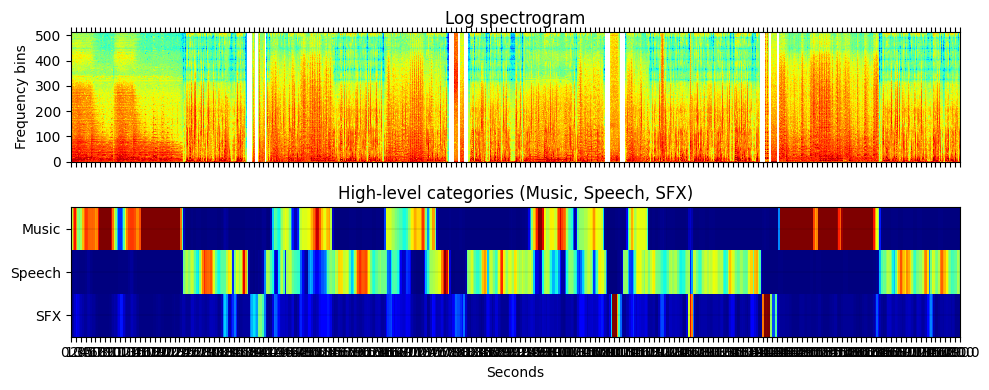

In [15]:
visualize_high_level_categories(
    raw_audio=res.audio,
    framewise_output=frame_wise_output,
)

In [12]:
import requests
ontology_url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"

ontology = requests.get(ontology_url).json()
id_to_name = {x['id']: x['name'] for x in ontology}

In [13]:
# Build parent lookup
child_to_parents = {}
id_to_name = {}

for node in ontology:
    id_to_name[node['id']] = node['name']
    for child_id in node.get('child_ids', []):
        if child_id not in child_to_parents:
            child_to_parents[child_id] = []
        child_to_parents[child_id].append(node['id'])

# Function to get all ancestors
def get_ancestors(class_id):
    ancestors = set()
    queue = [class_id]
    while queue:
        current = queue.pop(0)
        if current in child_to_parents:
            for parent in child_to_parents[current]:
                if parent not in ancestors:
                    ancestors.add(parent)
                    queue.append(parent)
    return ancestors

# Map to Speech/Music/SFX
def map_to_high_level(class_id):
    ancestors = get_ancestors(class_id)
    ancestor_names = {id_to_name[aid] for aid in ancestors}
    
    if 'Music' in ancestor_names:
        return 'Music'
    elif 'Speech' in ancestor_names or 'Human voice' in ancestor_names:
        return 'Speech'
    else:
        return 'SFX'  # Default to sound effects